# NASA Analytics 2010–2024 — ML Analysis
**Dataset:** NASA Launch & Budget Data | **Section A:** Machine Learning

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df = pd.read_csv('Nasa_Analytics_2010_2024.csv')
df.head()

,Company,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
0,NASA,2010,4,4,0,0,18700,18000,3,100.0
1,NASA,2011,5,5,0,0,18500,17500,3,100.0
2,NASA,2012,4,4,0,0,17700,17000,2,100.0
3,NASA,2013,4,4,0,0,16800,17000,2,100.0
4,NASA,2014,5,5,0,0,17600,17200,2,100.0


## 3. Descriptive Statistics

In [3]:
df.describe().round(2)

,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
count,15.00,15.00,15.00,15.0,15.0,15.00,15.00,15.00,15.0
mean,2017.00,7.07,7.07,0.0,0.0,20565.67,17900.00,2.73,100.0
std,4.47,2.34,2.34,0.0,0.0,2859.15,656.83,0.70,0.0
min,2010.00,4.00,4.00,0.0,0.0,16800.00,17000.00,2.00,100.0
25%,2013.50,5.00,5.00,0.0,0.0,18255.00,17450.00,2.00,100.0
50%,2017.00,7.00,7.00,0.0,0.0,19500.00,17900.00,3.00,100.0
75%,2020.50,8.50,8.50,0.0,0.0,22950.00,18350.00,3.00,100.0
max,2024.00,11.00,11.00,0.0,0.0,25400.00,19000.00,4.00,100.0


In [4]:
df.isnull().sum()

Company                 0
Year                    0
Launches                0
Successful              0
Failed                  0
Revenue_USD_M           0
Budget_Funding_USD_M    0
Employees               0
Rockets                 0
Success_Rate_%          0
dtype: int64

## 4. EDA — Seaborn Plots

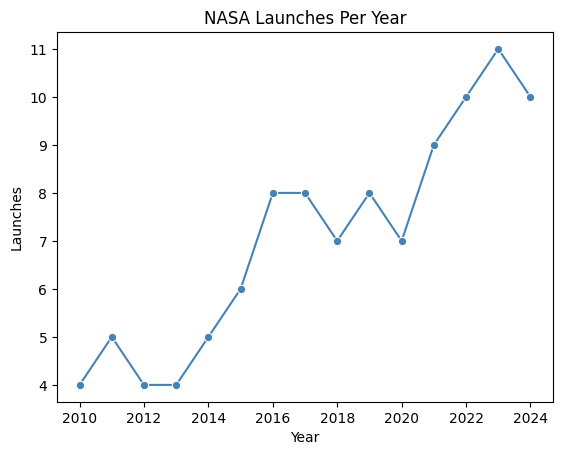

In [5]:
sns.lineplot(data=df, x='Year', y='Launches', marker='o', color='steelblue')
plt.title('NASA Launches Per Year')
plt.show()

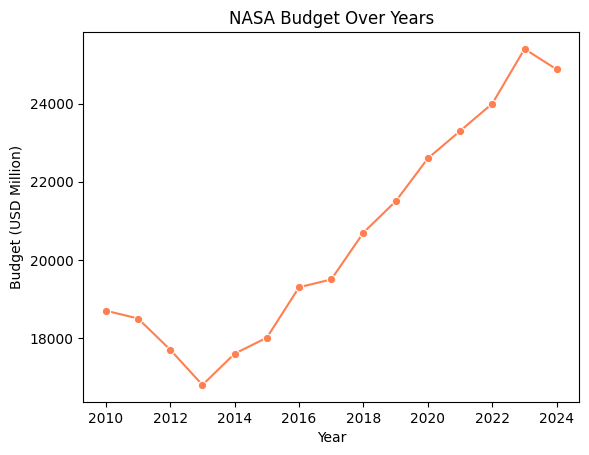

In [6]:
sns.lineplot(data=df, x='Year', y='Budget_Funding_USD_M', marker='o', color='coral')
plt.title('NASA Budget Over Years')
plt.ylabel('Budget (USD Million)')
plt.show()

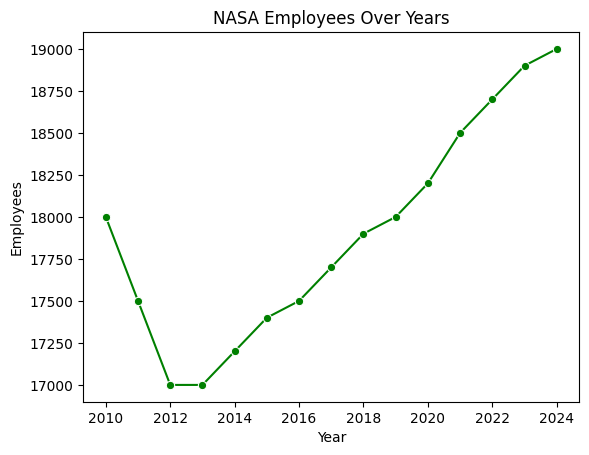

In [7]:
sns.lineplot(data=df, x='Year', y='Employees', marker='o', color='green')
plt.title('NASA Employees Over Years')
plt.show()

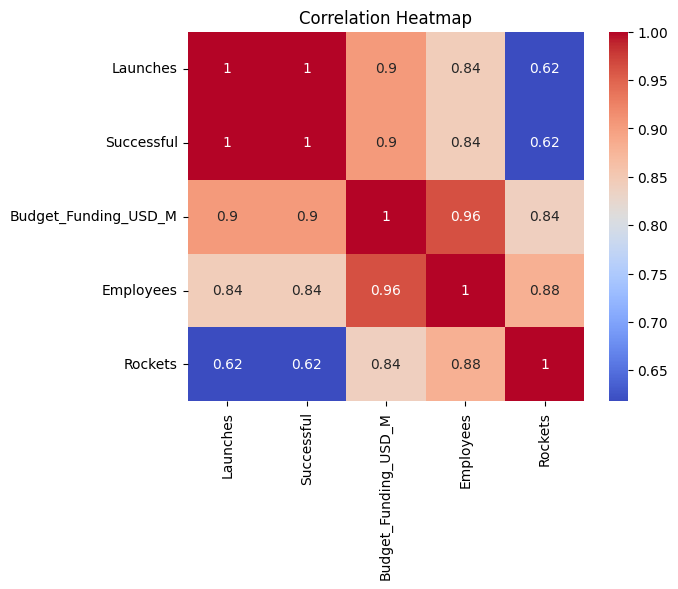

In [8]:
sns.heatmap(df[['Launches','Successful','Budget_Funding_USD_M','Employees','Rockets']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

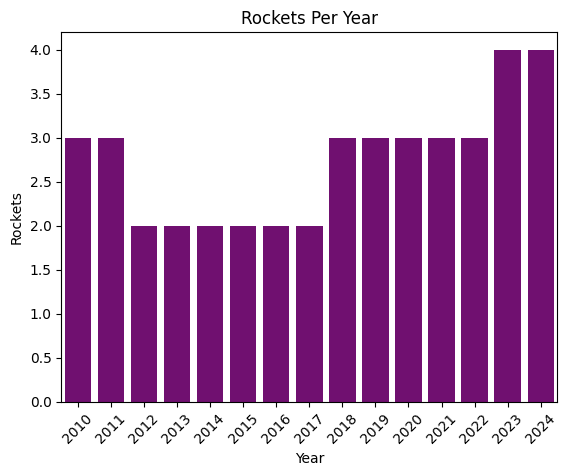

In [9]:
sns.barplot(data=df, x='Year', y='Rockets', color='purple')
plt.title('Rockets Per Year')
plt.xticks(rotation=45)
plt.show()

## 5. Feature Engineering

In [10]:
df['Budget_Per_Launch']    = df['Budget_Funding_USD_M'] / df['Launches']
df['Employee_Per_Rocket']  = df['Employees'] / df['Rockets']
df['Launch_Growth']        = df['Launches'].diff().fillna(0)
df['High_Activity']        = (df['Launches'] >= df['Launches'].median()).astype(int)

df[['Budget_Per_Launch','Employee_Per_Rocket','Launch_Growth','High_Activity']].head()

,Budget_Per_Launch,Employee_Per_Rocket,Launch_Growth,High_Activity
0,4675.0,6000.000000,0.0,0
1,3700.0,5833.333333,1.0,0
2,4425.0,8500.000000,-1.0,0
3,4200.0,8500.000000,0.0,0
4,3520.0,8600.000000,1.0,0


## 6. Regression — Predict Budget

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['Year','Launches','Employees','Rockets','Budget_Per_Launch','Launch_Growth']
X = df[features]
y = df['Budget_Funding_USD_M']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [12]:
models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    print(f"{name:25s} | MAE={mean_absolute_error(y_test,preds):.2f} | R²={r2_score(y_test,preds):.4f}")

Linear Regression         | MAE=746.41 | R²=0.7386
Random Forest             | MAE=381.80 | R²=0.9265
Gradient Boosting         | MAE=678.91 | R²=0.7680


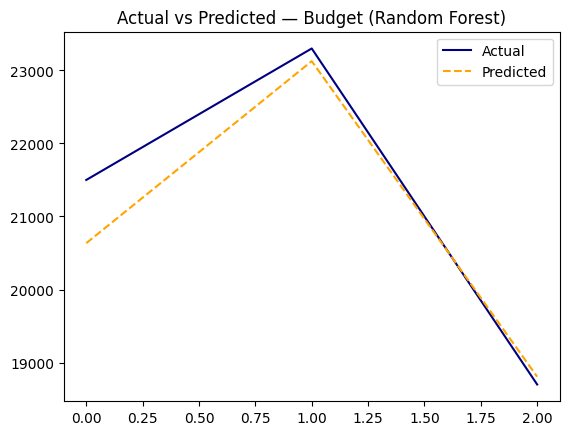

In [13]:
best_preds = models['Random Forest'].predict(X_test_sc)
plt.plot(y_test.values, label='Actual', color='navy')
plt.plot(best_preds, label='Predicted', color='orange', linestyle='--')
plt.title('Actual vs Predicted — Budget (Random Forest)')
plt.legend()
plt.show()

## 7. Classification — High vs Low Activity Year

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X2 = df[['Year','Launches','Employees','Rockets','Budget_Per_Launch','Launch_Growth']]
y2 = df['High_Activity']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
X2_train_sc = scaler.fit_transform(X2_train)
X2_test_sc  = scaler.transform(X2_test)

In [15]:
clfs = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, clf in clfs.items():
    clf.fit(X2_train_sc, y2_train)
    preds = clf.predict(X2_test_sc)
    print(f"{name:22s} | Accuracy={accuracy_score(y2_test,preds):.4f}")

Logistic Regression    | Accuracy=1.0000
Decision Tree          | Accuracy=1.0000
Random Forest          | Accuracy=1.0000


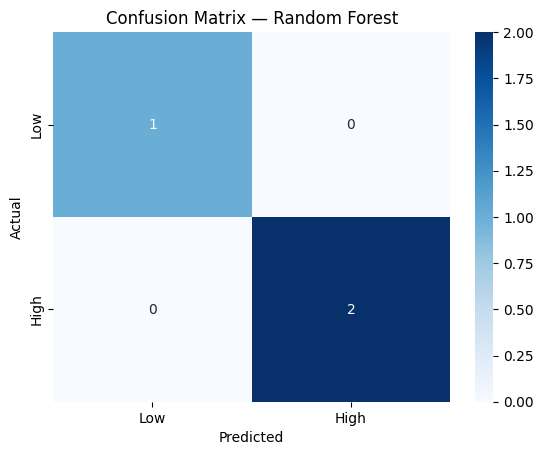

In [16]:
best_clf = clfs['Random Forest']
cm = confusion_matrix(y2_test, best_clf.predict(X2_test_sc))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Clustering — KMeans

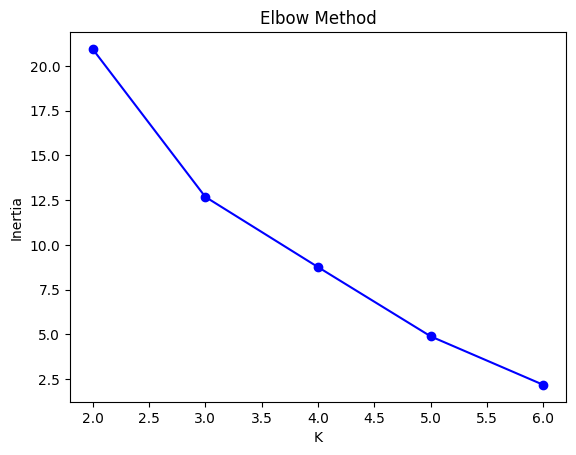

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X3 = df[['Launches','Budget_Funding_USD_M','Employees','Rockets']]
X3_sc = StandardScaler().fit_transform(X3)

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X3_sc).inertia_ for k in range(2,7)]
plt.plot(range(2,7), inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

Silhouette Score: 0.4146


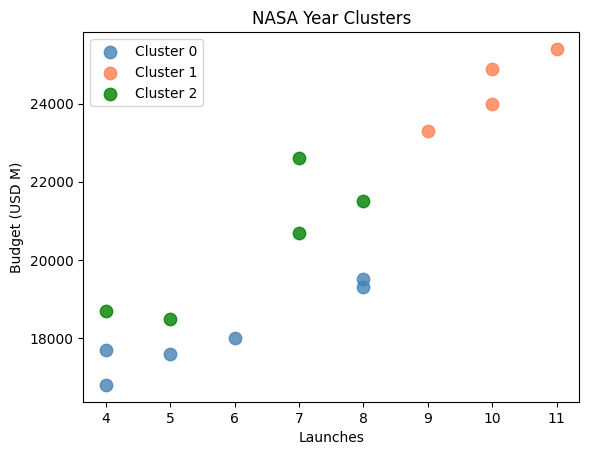

In [18]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X3_sc)
print("Silhouette Score:", round(silhouette_score(X3_sc, df['Cluster']), 4))

for cl, color in zip([0,1,2], ['steelblue','coral','green']):
    sub = df[df['Cluster']==cl]
    plt.scatter(sub['Launches'], sub['Budget_Funding_USD_M'],
                label=f'Cluster {cl}', alpha=0.8, color=color, s=80)
plt.xlabel('Launches')
plt.ylabel('Budget (USD M)')
plt.title('NASA Year Clusters')
plt.legend()
plt.show()

## 9. Ensemble Learning

In [19]:
from sklearn.ensemble import AdaBoostRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

ensembles = {
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost'          : AdaBoostRegressor(n_estimators=100, random_state=42),
    'Bagging'           : BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42),
}

for name, model in ensembles.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    cv = cross_val_score(model, X_train_sc, y_train, cv=3, scoring='r2').mean()
    print(f"{name:22s} | MAE={mean_absolute_error(y_test,preds):.2f} | R²={r2_score(y_test,preds):.4f} | CV={cv:.4f}")

Random Forest          | MAE=381.80 | R²=0.9265 | CV=0.8770
Gradient Boosting      | MAE=678.91 | R²=0.7680 | CV=0.8787
AdaBoost               | MAE=566.67 | R²=0.8911 | CV=0.8902
Bagging                | MAE=478.27 | R²=0.9137 | CV=0.8864


## 10. Save Models

In [20]:
import pickle

pickle.dump(models['Random Forest'],    open('nasa_regressor.pkl',  'wb'))
pickle.dump(clfs['Random Forest'],      open('nasa_classifier.pkl', 'wb'))
pickle.dump(ensembles['Gradient Boosting'], open('nasa_ensemble.pkl','wb'))

print("Models saved.")

Models saved.
